In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Ajout du chemin vers les scripts sources
sys.path.append('../src')
import utils

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score

# Chargement des données
X_train = pd.read_csv('../data/train_test/X_train.csv')
X_test  = pd.read_csv('../data/train_test/X_test.csv')
y_train = pd.read_csv('../data/train_test/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/train_test/y_test.csv').values.ravel()

print(f"Données prêtes : {X_train.shape[0]} lignes pour l'entraînement, {X_test.shape[0]} pour le test.")

Données prêtes : 3497 lignes pour l'entraînement, 875 pour le test.


In [2]:
print("--- ENTRAÎNEMENT : LOGISTIC REGRESSION (BASELINE) ---")
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_log):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_log):.4f}")

--- ENTRAÎNEMENT : LOGISTIC REGRESSION (BASELINE) ---
ROC-AUC : 0.7902
F1-Score : 0.6229


In [3]:
print("--- ENTRAÎNEMENT : RANDOM FOREST (DEFAULT) ---")
rf_default = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_default.fit(X_train, y_train)

y_pred_rf_def = rf_default.predict(X_test)
y_proba_rf_def = rf_default.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_rf_def):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf_def):.4f}")

--- ENTRAÎNEMENT : RANDOM FOREST (DEFAULT) ---
ROC-AUC : 0.7861
F1-Score : 0.5388


In [4]:
print("--- OPTIMISATION : RANDOM FOREST (GRID SEARCH) ---")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Meilleurs paramètres : {grid_search.best_params_}")

y_pred_rf_opt = best_rf.predict(X_test)
y_proba_rf_opt = best_rf.predict_proba(X_test)[:, 1]

--- OPTIMISATION : RANDOM FOREST (GRID SEARCH) ---
Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("--- OPTIMISATION DU GRADIENT BOOSTING ---")

# 1. Initialisation du modèle
gb = GradientBoostingClassifier(random_state=42)

# 2. Grille de paramètres (adaptée au Gradient Boosting)
param_grid_gb = {
    'n_estimators': [50, 100, 200],      # Nombre d'arbres séquentiels
    'learning_rate': [0.01, 0.1, 0.2],   # Vitesse d'apprentissage des erreurs
    'max_depth': [3, 5, 7]               # Profondeur (généralement plus faible que le RF)
}

# 3. Configuration de la recherche (Validation croisée à 5 plis)
grid_search_gb = GridSearchCV(
    estimator=gb, 
    param_grid=param_grid_gb, 
    cv=5, 
    scoring="roc_auc", 
    n_jobs=-1,   # Utilise tous les cœurs de ton processeur
    verbose=1    # Affiche l'avancement
)

print("Lancement de l'entraînement des combinaisons... (Cela peut prendre un peu de temps ☕)")
grid_search_gb.fit(X_train, y_train)

# 4. Affichage des meilleurs résultats trouvés
print(f"\n✅ Meilleurs hyperparamètres GB : {grid_search_gb.best_params_}")
print(f"✅ Meilleur score ROC-AUC (Validation Croisée) : {grid_search_gb.best_score_:.4f}")

# 5. Évaluation finale sur X_test
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

print("\n--- ÉVALUATION FINALE SUR LE JEU DE TEST (X_TEST) ---")
print("Rapport de Classification :")
print(classification_report(y_test, y_pred_gb, target_names=["Fidèle", "Churné"]))

roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print(f"Score ROC-AUC Final : {roc_auc_gb:.4f}")
print(f"Score F1 (Churn) Final : {f1_gb:.4f}")

--- OPTIMISATION DU GRADIENT BOOSTING ---
Lancement de l'entraînement des combinaisons... (Cela peut prendre un peu de temps ☕)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Meilleurs hyperparamètres GB : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
✅ Meilleur score ROC-AUC (Validation Croisée) : 0.7969

--- ÉVALUATION FINALE SUR LE JEU DE TEST (X_TEST) ---
Rapport de Classification :
              precision    recall  f1-score   support

      Fidèle       0.77      0.84      0.81       584
      Churné       0.61      0.49      0.55       291

    accuracy                           0.73       875
   macro avg       0.69      0.67      0.68       875
weighted avg       0.72      0.73      0.72       875

Score ROC-AUC Final : 0.7983
Score F1 (Churn) Final : 0.5475


d:\2eme_S2_ENIS\machineLearning\projet_ml_retail\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


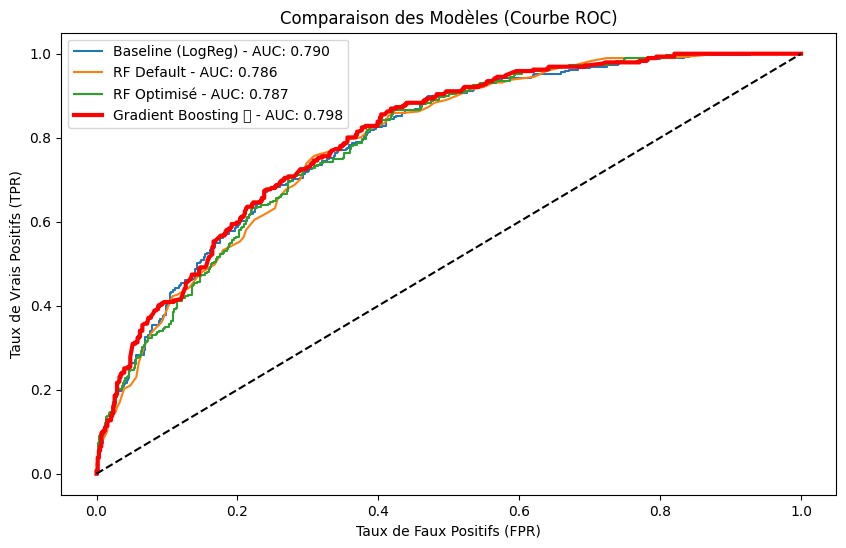

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Courbe ROC LogReg
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Baseline (LogReg) - AUC: {roc_auc_score(y_test, y_proba_log):.3f}')

# Courbe ROC RF Default
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_def)
plt.plot(fpr_rf, tpr_rf, label=f'RF Default - AUC: {roc_auc_score(y_test, y_proba_rf_def):.3f}')

# Courbe ROC RF Optimisé
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_rf_opt)
plt.plot(fpr_opt, tpr_opt, label=f'RF Optimisé - AUC: {roc_auc_score(y_test, y_proba_rf_opt):.3f}')

# --- NOUVEAU : Courbe ROC Gradient Boosting (Le Gagnant) ---
# Assure-toi que la variable y_proba_gb existe bien dans ton Notebook !
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting 🏆 - AUC: {roc_auc_score(y_test, y_proba_gb):.3f}', linewidth=3, color='red')

# Ligne du hasard (50%)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison des Modèles (Courbe ROC)')
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_732\2915887108.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances, palette='Reds_r')


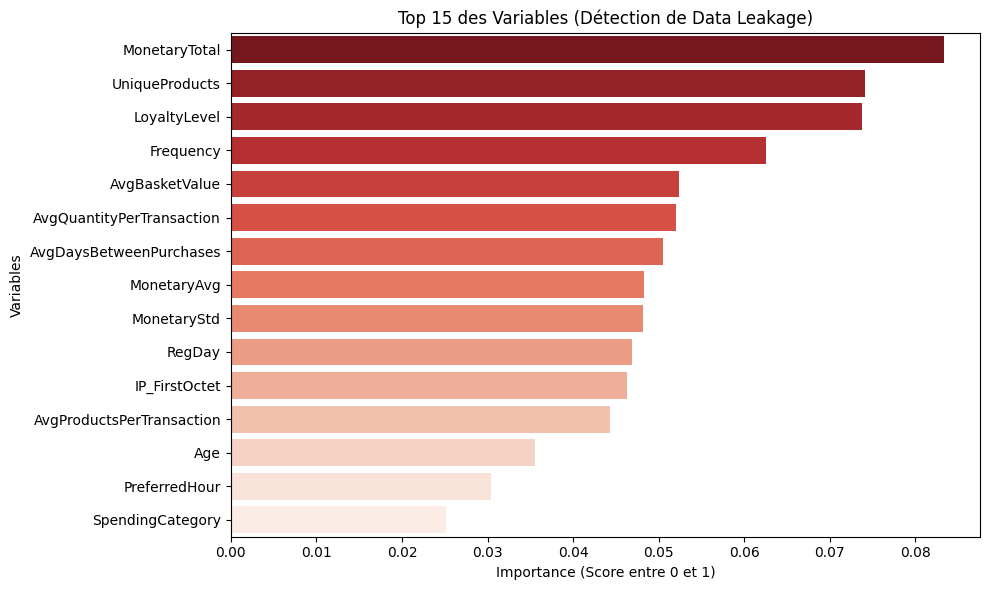

--- TOP 5 DES VARIABLES SUSPECTES ---
      Variable  Importance
 MonetaryTotal    0.083374
UniqueProducts    0.074111
  LoyaltyLevel    0.073702
     Frequency    0.062503
AvgBasketValue    0.052380


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# On récupère les importances du Random Forest (rf_default) que tu viens d'entraîner
importances = rf_default.feature_importances_
features = X_train.columns

# Création d'un DataFrame pour trier facilement
df_importances = pd.DataFrame({
    'Variable': features, 
    'Importance': importances
})

# On trie pour avoir les plus importantes en haut (on garde le Top 15)
df_importances = df_importances.sort_values(by='Importance', ascending=False).head(15)

# Affichage graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importances, palette='Reds_r')
plt.title("Top 15 des Variables (Détection de Data Leakage)")
plt.xlabel("Importance (Score entre 0 et 1)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# Affichage des valeurs exactes
print("--- TOP 5 DES VARIABLES SUSPECTES ---")
print(df_importances.head(5).to_string(index=False))

In [ ]:
# --- CORRECTION DU DATA LEAKAGE ---
# On supprime les variables "tricheuses" qui contiennent la réponse
colonnes_a_supprimer = ["Recency"] 
# On les retire de X_train et X_test
X_train = X_train.drop(columns=colonnes_a_supprimer, errors='ignore')
X_test = X_test.drop(columns=colonnes_a_supprimer, errors='ignore')

print(f"Nouvelles dimensions de X_train : {X_train.shape}")

Nouvelles dimensions de X_train : (3497, 44)
